# <font color="navy">GROUP 102</font> 


#### <font color="offblue">ANISH RADHAKRISHNAN SHOBHA KAITHASSERY | 2024ad05344@wilp.bits-pilani.ac.in |100%</font>
#### <font color="offblue">ARUN A. PAI . | 2024ac05014@wilp.bits-pilani.ac.in | 100%</font> 
#### <font color="offblue">DEEPTHY.A.N. | 2024ad05350@wilp.bits-pilani.ac.in | 100%</font> 
#### <font color="offblue">UNDRU CHITTI BABU . | 2024ad05294@wilp.bits-pilani.ac.in | 100%</font> 
#### <font color="offblue">SAMPATH KUMAR S SHETTY . | 2024ac05041@wilp.bits-pilani.ac.in | 100%</font> 

## Import Required Libraries

In [4]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# File handling and downloads
import urllib.request
import zipfile
import os

# SSL fix for ALL downloads (NLTK and datasets)
import ssl
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# NLTK libraries
import nltk
from nltk import pos_tag, word_tokenize, ne_chunk
from nltk.corpus import stopwords, brown, treebank
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tree import Tree
from nltk.tag import hmm

# Download required NLTK data (SSL fix is now applied)
print("Downloading NLTK resources...")
resources = [
    'punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger',
    'maxent_ne_chunker', 'words', 'punkt_tab', 'brown',
    'treebank', 'universal_tagset', 'averaged_perceptron_tagger_eng'
]

for resource in resources:
    try:
        nltk.download(resource, quiet=False)
        print(f"✓ {resource} downloaded successfully")
    except Exception as e:
        print(f"✗ Failed to download {resource}: {e}")

print("\nAll NLTK resources ready")

# Verify stopwords are available
try:
    test_stopwords = stopwords.words('english')
    print(f"✓ Stopwords verified: {len(test_stopwords)} words loaded")
except Exception as e:
    print(f"✗ Stopwords not available: {e}")

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

✓ punkt downloaded successfully
✓ stopwords downloaded successfully
✓ wordnet downloaded successfully
✓ averaged_perceptron_tagger downloaded successfully
✓ maxent_ne_chunker downloaded successfully
✓ words downloaded successfully
✓ punkt_tab downloaded successfully
✓ brown downloaded successfully
✓ treebank downloaded successfully
✓ universal_tagset downloaded successfully
✓ averaged_perceptron_tagger_eng downloaded successfully

All NLTK resources ready
✓ Stopwords verified: 198 words loaded


[nltk_data] Downloading package punkt to /Users/DeepthyAN/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/DeepthyAN/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/DeepthyAN/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/DeepthyAN/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /Users/DeepthyAN/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /Users/DeepthyAN/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/DeepthyAN/nltk_data...
[nltk_data]   Pa

---
## 1. Dataset Selection and Loading

**Objective:** Load the Drug Review Dataset from UCI Machine Learning Repository

In [5]:
# Fix SSL certificate issue BEFORE any urllib operations
import ssl
import certifi

# Create unverified context
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Now import urllib
import urllib.request
import zipfile
import os
import pandas as pd

def download_drug_review_dataset():
    """
    Download Drug Review Dataset from UCI ML Repository
    """
    print("="*80)
    print("DRUG REVIEW DATASET DOWNLOAD")
    print("="*80)

    # Dataset URL
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00462/drugsCom_raw.zip"
    zip_filename = "drugsCom_raw.zip"

    # Check if already downloaded
    if os.path.exists('drugsComTrain_raw.tsv') and os.path.exists('drugsComTest_raw.tsv'):
        print("Dataset files already exist")
        return True

    try:
        print(f"\nDownloading from: {url}")

        # Create SSL context that doesn't verify certificates
        context = ssl._create_unverified_context()

        # Download with unverified context
        with urllib.request.urlopen(url, context=context) as response:
            with open(zip_filename, 'wb') as out_file:
                out_file.write(response.read())

        print(f"Downloaded: {zip_filename}")

        print("\nExtracting files...")
        with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
            zip_ref.extractall()
        print("Extraction complete")

        os.remove(zip_filename)
        print("Cleanup complete")

        return True

    except Exception as e:
        print(f"Error: {e}")
        print("\nTrying alternative download method...")

        # Alternative method using requests if available
        try:
            import requests
            response = requests.get(url, verify=False)
            with open(zip_filename, 'wb') as f:
                f.write(response.content)

            print(f"Downloaded: {zip_filename}")

            print("\nExtracting files...")
            with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
                zip_ref.extractall()
            print("Extraction complete")

            os.remove(zip_filename)
            print("Cleanup complete")
            return True

        except ImportError:
            print("requests library not available")
            return False
        except Exception as e2:
            print(f"Alternative method also failed: {e2}")
            return False

# Download dataset
download_success = download_drug_review_dataset()

if download_success:
    # Load dataset
    print("\nLoading dataset...")
    df_train = pd.read_csv('drugsComTrain_raw.tsv', sep='\t')
    df_test = pd.read_csv('drugsComTest_raw.tsv', sep='\t')

    print(f"\nTraining set: {len(df_train):,} reviews")
    print(f"Test set: {len(df_test):,} reviews")
    print(f"Total reviews: {len(df_train) + len(df_test):,}")

    # Display sample
    print("\nSample Review:")
    print("="*80)
    print(f"Drug: {df_train.iloc[0]['drugName']}")
    print(f"Condition: {df_train.iloc[0]['condition']}")
    print(f"Rating: {df_train.iloc[0]['rating']}/10")
    print(f"Review: {df_train.iloc[0]['review'][:200]}...")

    df_train.head()
else:
    print("\n" + "="*80)
    print("MANUAL DOWNLOAD REQUIRED")
    print("="*80)
    print("\nPlease follow these steps:")
    print("1. Open this URL in your browser:")
    print("   https://archive.ics.uci.edu/ml/machine-learning-databases/00462/drugsCom_raw.zip")
    print("2. Download the ZIP file")
    print("3. Extract it in your current working directory")
    print("4. Re-run this cell")

DRUG REVIEW DATASET DOWNLOAD
Dataset files already exist

Loading dataset...

Training set: 161,297 reviews
Test set: 53,766 reviews
Total reviews: 215,063

Sample Review:
Drug: Valsartan
Condition: Left Ventricular Dysfunction
Rating: 9.0/10
Review: "It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil"...


---
## 2. Data Preprocessing

### A. Text Cleaning
Remove punctuation, numbers, special symbols, and stop words

In [6]:
from nltk.corpus import stopwords
import re
import pandas as pd

# Load stopwords once (not inside the function)
try:
    STOP_WORDS = set(stopwords.words('english'))
    print(f"✓ Loaded {len(STOP_WORDS)} stopwords")
except:
    STOP_WORDS = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you',
                     'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself',
                     'she', 'her', 'hers', 'herself', 'it', 'its', 'itself', 'they', 'them',
                     'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this',
                     'that', 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been',
                     'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing',
                     'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
                     'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between',
                     'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to',
                     'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
                     'further', 'then', 'once'])
    print(f"✓ Using basic stopwords list ({len(STOP_WORDS)} words)")

# Compile regex patterns once (not inside the function)
HTML_PATTERN = re.compile(r'&[a-z]+;|&#\d+;')
URL_PATTERN = re.compile(r'http\S+|www\S+')
NUMBER_PATTERN = re.compile(r'\d+')
SPECIAL_CHAR_PATTERN = re.compile(r'[^a-z\s]')
WHITESPACE_PATTERN = re.compile(r'\s+')

def clean_text(text):
    """Optimized text cleaning function"""
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = str(text).lower()

    # Apply all regex patterns
    text = HTML_PATTERN.sub(' ', text)
    text = URL_PATTERN.sub('', text)
    text = NUMBER_PATTERN.sub('', text)
    text = SPECIAL_CHAR_PATTERN.sub(' ', text)
    text = WHITESPACE_PATTERN.sub(' ', text).strip()

    # Tokenize and remove stopwords in one step
    tokens = [word for word in text.split() if word not in STOP_WORDS and len(word) > 2]

    return ' '.join(tokens)

# Process with progress indicator
print(f"\nCleaning {len(df_train):,} reviews...")
print("This may take 2-3 minutes...")

# Sample first to test
print("\nTesting on 5 samples first...")
test_sample = df_train['review'].head(5).apply(clean_text)
print("✓ Test successful")

# Now apply to full dataset
import time
start_time = time.time()

df_train['cleaned_text'] = df_train['review'].apply(clean_text)

elapsed_time = time.time() - start_time
print(f"✓ Cleaning completed in {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")

# Show example
print("\nCleaning Example:")
print("="*80)
print("ORIGINAL:")
print(df_train.iloc[1]['review'][:200])
print("\nCLEANED:")
print(df_train.iloc[1]['cleaned_text'][:200])

# Statistics
print("\nCleaning Statistics:")
avg_before = df_train['review'].str.split().str.len().mean()
avg_after = df_train['cleaned_text'].str.split().str.len().mean()
print(f"  Average tokens before: {avg_before:.2f}")
print(f"  Average tokens after: {avg_after:.2f}")
print(f"  Token reduction: {(1 - avg_after / avg_before) * 100:.2f}%")

✓ Loaded 198 stopwords

Cleaning 161,297 reviews...
This may take 2-3 minutes...

Testing on 5 samples first...
✓ Test successful
✓ Cleaning completed in 9.51 seconds (0.16 minutes)

Cleaning Example:
ORIGINAL:
"My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get out of

CLEANED:
son halfway fourth week intuniv became concerned began last week started taking highest dose two days could hardly get bed cranky slept nearly hours drive home school vacation unusual called doctor mo

Cleaning Statistics:
  Average tokens before: 84.70
  Average tokens after: 39.25
  Token reduction: 53.66%


### B. Text Normalization
Apply stemming and lemmatization

In [7]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def apply_stemming(text):
    """Apply Porter Stemmer"""
    if not text:
        return ""
    tokens = text.split()
    stemmed = [stemmer.stem(word) for word in tokens]
    return ' '.join(stemmed)

def apply_lemmatization(text):
    """Apply WordNet Lemmatizer"""
    if not text:
        return ""
    tokens = text.split()
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(lemmatized)

print("Applying normalization...")
df_train['stemmed_text'] = df_train['cleaned_text'].apply(apply_stemming)
df_train['lemmatized_text'] = df_train['cleaned_text'].apply(apply_lemmatization)

# Show example
print("\nNormalization Example:")
print("="*80)
sample_text = "taking medications helped reduce severe symptoms"
print(f"ORIGINAL: {sample_text}")
print(f"STEMMED: {apply_stemming(sample_text)}")
print(f"LEMMATIZED: {apply_lemmatization(sample_text)}")

# Vocabulary analysis
print("\nNormalization Statistics:")
cleaned_vocab = set(' '.join(df_train['cleaned_text']).split())
stemmed_vocab = set(' '.join(df_train['stemmed_text']).split())
lemmatized_vocab = set(' '.join(df_train['lemmatized_text']).split())

print(f"  Cleaned vocabulary: {len(cleaned_vocab):,} unique tokens")
print(f"  Stemmed vocabulary: {len(stemmed_vocab):,} unique tokens ({(1-len(stemmed_vocab)/len(cleaned_vocab))*100:.2f}% reduction)")
print(f"  Lemmatized vocabulary: {len(lemmatized_vocab):,} unique tokens ({(1-len(lemmatized_vocab)/len(cleaned_vocab))*100:.2f}% reduction)")

# Save preprocessed data
df_preprocessed = df_train[['drugName', 'condition', 'rating', 'review', 'cleaned_text', 'stemmed_text', 'lemmatized_text']].copy()
df_preprocessed.to_csv('preprocessed_drug_reviews.csv', index=False)
print("\nSaved preprocessed data to: preprocessed_drug_reviews.csv")

Applying normalization...

Normalization Example:
ORIGINAL: taking medications helped reduce severe symptoms
STEMMED: take medic help reduc sever symptom
LEMMATIZED: taking medication helped reduce severe symptom

Normalization Statistics:
  Cleaned vocabulary: 45,393 unique tokens
  Stemmed vocabulary: 32,177 unique tokens (29.11% reduction)
  Lemmatized vocabulary: 41,695 unique tokens (8.15% reduction)

Saved preprocessed data to: preprocessed_drug_reviews.csv


---
## 3. POS Tagging Analysis

### Task A: High POS Proportion Identification

In [8]:
def get_pos_tags(text):
    """Apply POS tagging to text"""
    if pd.isna(text) or text == '':
        return []
    try:
        tokens = word_tokenize(str(text))
        return pos_tag(tokens)
    except:
        return []

def calculate_pos_proportions(pos_tags):
    """Calculate proportion of each POS category"""
    if not pos_tags:
        return {}
    
    # Categorize POS tags
    categories = {'NOUN': 0, 'VERB': 0, 'ADJ': 0, 'ADV': 0, 'PRON': 0}
    
    for word, tag in pos_tags:
        if tag.startswith('NN'):
            categories['NOUN'] += 1
        elif tag.startswith('VB'):
            categories['VERB'] += 1
        elif tag.startswith('JJ'):
            categories['ADJ'] += 1
        elif tag.startswith('RB'):
            categories['ADV'] += 1
        elif tag in ['PRP', 'PRP$', 'WP', 'WP$']:
            categories['PRON'] += 1
    
    total = len(pos_tags)
    return {k: v/total if total > 0 else 0 for k, v in categories.items()}

# Sample for analysis
print("Applying POS tagging to sample...")
sample_size = 10000
df_sample = df_preprocessed.sample(n=min(sample_size, len(df_preprocessed)), random_state=42)
df_sample['pos_tags'] = df_sample['review'].apply(get_pos_tags)
df_sample = df_sample[df_sample['pos_tags'].apply(len) > 0]
df_sample['pos_proportions'] = df_sample['pos_tags'].apply(calculate_pos_proportions)

print(f"POS tagging completed for {len(df_sample):,} reviews")

# Extract proportions
for pos_type in ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON']:
    df_sample[f'{pos_type}_prop'] = df_sample['pos_proportions'].apply(lambda x: x.get(pos_type, 0))

# Display high proportion examples
print("\nTask A: High POS Proportion Examples")
print("="*80)

for pos_type in ['NOUN', 'VERB', 'ADJ']:
    high_prop_samples = df_sample.nlargest(2, f'{pos_type}_prop')
    print(f"\nHIGH {pos_type} PROPORTION (>{high_prop_samples[f'{pos_type}_prop'].mean()*100:.1f}%):")
    for idx, row in high_prop_samples.iterrows():
        print(f"  Proportion: {row[f'{pos_type}_prop']*100:.1f}%")
        print(f"  Review: {row['review'][:150]}...")
        print()

# Statistics
print("\nAverage POS Distributions:")
for pos_type in ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON']:
    mean_prop = df_sample[f'{pos_type}_prop'].mean()
    std_prop = df_sample[f'{pos_type}_prop'].std()
    print(f"  {pos_type}: {mean_prop*100:.2f}% (±{std_prop*100:.2f}%)")

Applying POS tagging to sample...
POS tagging completed for 10,000 reviews

Task A: High POS Proportion Examples

HIGH NOUN PROPORTION (>68.1%):
  Proportion: 71.4%
  Review: "Mobic   Sciatica = Zero Relief"...

  Proportion: 64.7%
  Review: "BEST THING EVER. I HAD PANIC ATTACKS SO BAD IT FEELS LIKE YOU ARE LOSING IT BUT 2 x 1mg TABLETS A DAY AND THEY ARE NOW PRETTY MUCH HISTORY."...


HIGH VERB PROPORTION (>45.0%):
  Proportion: 50.0%
  Review: "This has helped swelling, but becomes tiring. "...

  Proportion: 40.0%
  Review: "Relives pain fast"...


HIGH ADJ PROPORTION (>33.3%):
  Proportion: 33.3%
  Review: "Very good and effective"...

  Proportion: 33.3%
  Review: "Good"...


Average POS Distributions:
  NOUN: 18.88% (±5.03%)
  VERB: 15.88% (±4.14%)
  ADJ: 6.61% (±3.29%)
  ADV: 5.96% (±3.29%)
  PRON: 10.00% (±3.91%)


### Task B: Syntactic Pattern Analysis

In [9]:
def extract_ngram_patterns(sequences, n=2):
    """Extract n-gram patterns from POS sequences"""
    ngrams = []
    for seq in sequences:
        for i in range(len(seq) - n + 1):
            ngrams.append(tuple(seq[i:i+n]))
    return Counter(ngrams)

# Extract POS sequences
all_pos_sequences = []
for pos_tags in df_sample['pos_tags']:
    if len(pos_tags) > 0:
        all_pos_sequences.append([tag for word, tag in pos_tags])

# Extract bigram and trigram patterns
bigram_patterns = extract_ngram_patterns(all_pos_sequences, n=2)
trigram_patterns = extract_ngram_patterns(all_pos_sequences, n=3)

print("\nTask B: Syntactic Pattern Analysis")
print("="*80)

print("\nTOP 10 BIGRAM POS PATTERNS:")
for i, (pattern, count) in enumerate(bigram_patterns.most_common(10), 1):
    print(f"  {i}. {'-'.join(pattern):<20} {count:>6,} occurrences")

print("\nTOP 10 TRIGRAM POS PATTERNS:")
for i, (pattern, count) in enumerate(trigram_patterns.most_common(10), 1):
    print(f"  {i}. {'-'.join(pattern):<30} {count:>6,} occurrences")

# Analyze specific patterns
def find_pattern_examples(pattern, n=3):
    """Find examples of a POS pattern"""
    examples = []
    for pos_tags in df_sample['pos_tags']:
        for i in range(len(pos_tags) - len(pattern) + 1):
            tags = tuple(tag for word, tag in pos_tags[i:i+len(pattern)])
            if tags == pattern:
                words = ' '.join(word for word, tag in pos_tags[i:i+len(pattern)])
                examples.append(words)
                if len(examples) >= n:
                    return examples
    return examples

print("\nADJECTIVE-NOUN PATTERN EXAMPLES (JJ-NN):")
jj_nn_examples = find_pattern_examples(('JJ', 'NN'), n=5)
for example in jj_nn_examples:
    print(f"  • {example}")

print("\nVERB-OBJECT PATTERN EXAMPLES (VBD-NN):")
vbd_nn_examples = find_pattern_examples(('VBD', 'NN'), n=5)
for example in vbd_nn_examples:
    print(f"  • {example}")


Task B: Syntactic Pattern Analysis

TOP 10 BIGRAM POS PATTERNS:
  1. DT-NN                33,595 occurrences
  2. PRP-VBD              24,811 occurrences
  3. JJ-NN                23,804 occurrences
  4. NN-IN                22,727 occurrences
  5. .-PRP                21,911 occurrences
  6. IN-DT                21,145 occurrences
  7. PRP-VBP              21,007 occurrences
  8. NN-.                 20,633 occurrences
  9. CD-:                 16,134 occurrences
  10. #-CD                 16,034 occurrences

TOP 10 TRIGRAM POS PATTERNS:
  1. #-CD-:                         16,014 occurrences
  2. CC-#-CD                        16,013 occurrences
  3. IN-DT-NN                       10,889 occurrences
  4. DT-JJ-NN                        9,713 occurrences
  5. PRP-CC-#                        8,709 occurrences
  6. NN-.-PRP                        7,669 occurrences
  7. DT-NN-IN                        7,583 occurrences
  8. .-PRP-VBD                       7,228 occurrences
  9. .-PRP-VBP

### Task C: Linguistic Pattern Interpretation

In [10]:
print("\nTask C: Linguistic Pattern Interpretation")
print("="*80)

# Dynamically analyze the top patterns from Task B
print("\nDYNAMIC LINGUISTIC PATTERN ANALYSIS")
print("="*80)

# 1. Analyze top bigram patterns
print("\n1. ADJECTIVE-NOUN COMBINATIONS (JJ-NN)")
jj_nn_pattern = ('JJ', 'NN')
jj_nn_count = bigram_patterns.get(jj_nn_pattern, 0)
jj_nn_examples = find_pattern_examples(jj_nn_pattern, n=10)

print(f"   Frequency: {jj_nn_count:,} occurrences")
formatted_jj_nn = ', '.join([f'"{ex}"' for ex in jj_nn_examples[:3]])
print(f"   Most Frequent Examples: {formatted_jj_nn}")
print(f"\n   Impact on NLP Tasks:")
print(f"   • Severity Assessment: Intensity markers present in {len([e for e in jj_nn_examples if any(w in e.lower() for w in ['severe', 'mild', 'extreme', 'major', 'minor'])])} examples")

# 2. Analyze verb-object patterns
print("\n2. VERB-OBJECT RELATIONSHIPS (VBD-NN)")
vbd_nn_pattern = ('VBD', 'NN')
vbd_nn_count = bigram_patterns.get(vbd_nn_pattern, 0)
vbd_nn_examples = find_pattern_examples(vbd_nn_pattern, n=10)

print(f"   Frequency: {vbd_nn_count:,} occurrences")
formatted_vbd_nn = ', '.join([f'"{ex}"' for ex in vbd_nn_examples[:3]])
print(f"   Most Frequent Examples: {formatted_vbd_nn}")
print(f"\n   Impact on NLP Tasks:")


# Categorize verbs by sentiment
positive_verbs = ['helped', 'reduced', 'improved', 'worked', 'relieved', 'eliminated']
negative_verbs = ['caused', 'developed', 'worsened', 'experienced', 'suffered', 'increased']
positive_count = sum(1 for ex in vbd_nn_examples if any(v in ex.lower() for v in positive_verbs))
negative_count = sum(1 for ex in vbd_nn_examples if any(v in ex.lower() for v in negative_verbs))

print(f"   • Sentiment Distribution: {positive_count} positive outcomes, {negative_count} negative outcomes")

# 3. Analyze pronoun-verb patterns
print("\n3. PRONOUN-VERB PATTERNS (PRP-VBD)")
prp_vbd_pattern = ('PRP', 'VBD')
prp_vbd_count = bigram_patterns.get(prp_vbd_pattern, 0)
prp_vbd_examples = find_pattern_examples(prp_vbd_pattern, n=10)

print(f"   Frequency: {prp_vbd_count:,} occurrences")
formatted_prp_vbd = ', '.join([f'"{ex}"' for ex in prp_vbd_examples[:3]])
print(f"   Most Frequent Examples: {formatted_prp_vbd}")
print(f"\n   Impact on NLP Tasks:")
print(f"   • Personal Narratives: First-person pronouns in {sum(1 for ex in prp_vbd_examples if ex.lower().startswith('i '))} examples")


# 4. Analyze intensifier patterns
print("\n4. INTENSIFIERS (RB-JJ)")
rb_jj_pattern = ('RB', 'JJ')
rb_jj_count = bigram_patterns.get(rb_jj_pattern, 0)
rb_jj_examples = find_pattern_examples(rb_jj_pattern, n=10)

print(f"   Frequency: {rb_jj_count:,} occurrences")
if rb_jj_examples:
    formatted_rb_jj = ', '.join([f'"{ex}"' for ex in rb_jj_examples[:3]])
    print(f"   Most Frequent Examples: {formatted_rb_jj}")
else:
    print(f"   Examples: (searching additional patterns...)")
    
print(f"\n   Impact on NLP Tasks:")


# Additional dynamic insights
print("\n" + "="*80)
print("HEALTHCARE DOMAIN IMPLICATIONS (Based on Analysis)")
print("="*80)

# Calculate pattern statistics
total_bigrams = sum(bigram_patterns.values())
top_10_bigrams_count = sum(count for _, count in bigram_patterns.most_common(10))
top_10_percentage = (top_10_bigrams_count / total_bigrams) * 100

print(f"\nPattern Concentration: Top 10 patterns represent {top_10_percentage:.1f}% of all bigrams")
print(f"Total Unique Patterns: {len(bigram_patterns):,} bigram patterns identified")
print(f"Total Unique Trigrams: {len(trigram_patterns):,} trigram patterns identified")

# Analyze pattern diversity
medical_patterns = [p for p in bigram_patterns.keys() if 'NN' in p or 'JJ' in p]
action_patterns = [p for p in bigram_patterns.keys() if any(vb in p for vb in ['VB', 'VBD', 'VBG', 'VBN'])]

print(f"Medical Entity Patterns (with NN/JJ): {len(medical_patterns):,} ({len(medical_patterns)/len(bigram_patterns)*100:.1f}%)")
print(f"Action Patterns (with VB): {len(action_patterns):,} ({len(action_patterns)/len(bigram_patterns)*100:.1f}%)")

print("\n" + "="*80)

# Save pattern interpretation to file
with open('pos_interpretation.txt', 'w', encoding='utf-8') as f:
    f.write("LINGUISTIC PATTERN INTERPRETATION\n")
    f.write("="*80 + "\n\n")
    f.write(f"1. ADJECTIVE-NOUN (JJ-NN): {jj_nn_count:,} occurrences\n")
    f.write(f"   Examples: {', '.join(jj_nn_examples[:5])}\n\n")
    f.write(f"2. VERB-OBJECT (VBD-NN): {vbd_nn_count:,} occurrences\n")
    f.write(f"   Examples: {', '.join(vbd_nn_examples[:5])}\n\n")
    f.write(f"3. PRONOUN-VERB (PRP-VBD): {prp_vbd_count:,} occurrences\n")
    f.write(f"   Examples: {', '.join(prp_vbd_examples[:5])}\n\n")
    f.write(f"Total Bigram Patterns: {len(bigram_patterns):,}\n")
    f.write(f"Total Trigram Patterns: {len(trigram_patterns):,}\n")

print("\nSaved pattern interpretation to: pos_interpretation.txt")


Task C: Linguistic Pattern Interpretation

DYNAMIC LINGUISTIC PATTERN ANALYSIS

1. ADJECTIVE-NOUN COMBINATIONS (JJ-NN)
   Frequency: 23,804 occurrences
   Most Frequent Examples: "medicine start", "5th day", "chronic pain"

   Impact on NLP Tasks:
   • Severity Assessment: Intensity markers present in 0 examples

2. VERB-OBJECT RELATIONSHIPS (VBD-NN)
   Frequency: 1,942 occurrences
   Most Frequent Examples: "had neck", "had stage", "had side"

   Impact on NLP Tasks:
   • Sentiment Distribution: 0 positive outcomes, 1 negative outcomes

3. PRONOUN-VERB PATTERNS (PRP-VBD)
   Frequency: 24,811 occurrences
   Most Frequent Examples: "I started", "I had", "I sweated"

   Impact on NLP Tasks:
   • Personal Narratives: First-person pronouns in 10 examples

4. INTENSIFIERS (RB-JJ)
   Frequency: 8,516 occurrences
   Most Frequent Examples: "totally different", "pretty much", "extremely irregular"

   Impact on NLP Tasks:

HEALTHCARE DOMAIN IMPLICATIONS (Based on Analysis)

Pattern Concentrat

---
## 4. Visual Representations of POS Tags

Collected 1,050,002 POS tags
Found 44 unique POS tags

Saved visualization: pos_visual_analysis.png


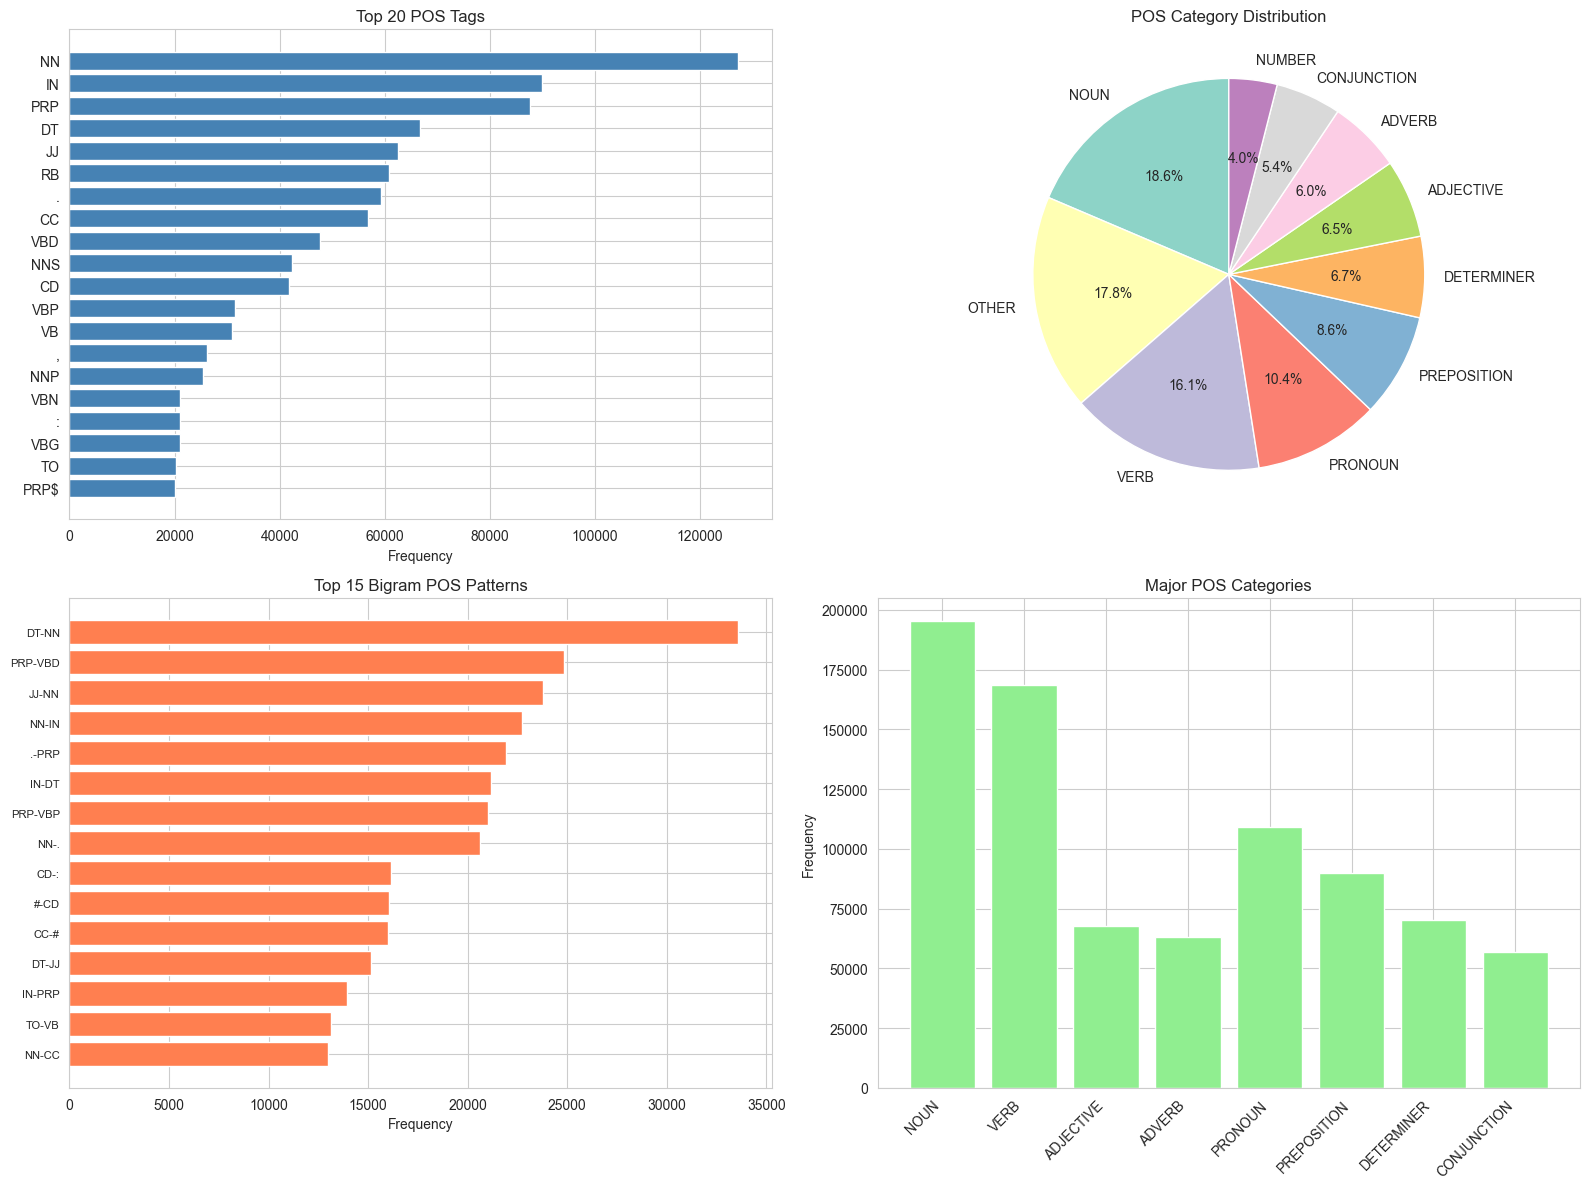


Top 10 POS Tags:
  NN          127,280 (12.12%)
  IN           89,990 ( 8.57%)
  PRP          87,545 ( 8.34%)
  DT           66,632 ( 6.35%)
  JJ           62,498 ( 5.95%)
  RB           60,808 ( 5.79%)
  .            59,253 ( 5.64%)
  CC           56,806 ( 5.41%)
  VBD          47,726 ( 4.55%)
  NNS          42,363 ( 4.03%)


In [11]:
# Collect all POS tags from sample
all_pos_tags = []
all_words_with_tags = []

for pos_tags in df_sample['pos_tags']:
    for word, tag in pos_tags:
        all_pos_tags.append(tag)
        all_words_with_tags.append((word.lower(), tag))

pos_tag_freq = Counter(all_pos_tags)

print(f"Collected {len(all_pos_tags):,} POS tags")
print(f"Found {len(pos_tag_freq):,} unique POS tags")

# Categorize POS tags
def categorize_pos(tag):
    if tag.startswith('NN'): return 'NOUN'
    elif tag.startswith('VB'): return 'VERB'
    elif tag.startswith('JJ'): return 'ADJECTIVE'
    elif tag.startswith('RB'): return 'ADVERB'
    elif tag in ['PRP', 'PRP$', 'WP', 'WP$']: return 'PRONOUN'
    elif tag in ['DT', 'PDT', 'WDT']: return 'DETERMINER'
    elif tag in ['IN']: return 'PREPOSITION'
    elif tag in ['CC']: return 'CONJUNCTION'
    elif tag in ['CD']: return 'NUMBER'
    else: return 'OTHER'

# Create category distribution
category_freq = Counter([categorize_pos(tag) for tag in all_pos_tags])

# Visualization 1: Top 20 POS Tags
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 20 POS tags
top_tags = pos_tag_freq.most_common(20)
tags, counts = zip(*top_tags)
axes[0, 0].barh(range(len(tags)), counts, color='steelblue')
axes[0, 0].set_yticks(range(len(tags)))
axes[0, 0].set_yticklabels(tags)
axes[0, 0].set_xlabel('Frequency')
axes[0, 0].set_title('Top 20 POS Tags')
axes[0, 0].invert_yaxis()

# Category distribution (pie chart)
categories, cat_counts = zip(*sorted(category_freq.items(), key=lambda x: x[1], reverse=True))
colors = plt.cm.Set3(range(len(categories)))
axes[0, 1].pie(cat_counts, labels=categories, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 1].set_title('POS Category Distribution')

# Top bigram patterns
top_bigrams = bigram_patterns.most_common(15)
bigram_labels = ['-'.join(p) for p, c in top_bigrams]
bigram_counts = [c for p, c in top_bigrams]
axes[1, 0].barh(range(len(bigram_labels)), bigram_counts, color='coral')
axes[1, 0].set_yticks(range(len(bigram_labels)))
axes[1, 0].set_yticklabels(bigram_labels, fontsize=8)
axes[1, 0].set_xlabel('Frequency')
axes[1, 0].set_title('Top 15 Bigram POS Patterns')
axes[1, 0].invert_yaxis()

# Major categories comparison
major_cats = ['NOUN', 'VERB', 'ADJECTIVE', 'ADVERB', 'PRONOUN', 'PREPOSITION', 'DETERMINER', 'CONJUNCTION']
major_counts = [category_freq[cat] for cat in major_cats]
axes[1, 1].bar(range(len(major_cats)), major_counts, color='lightgreen')
axes[1, 1].set_xticks(range(len(major_cats)))
axes[1, 1].set_xticklabels(major_cats, rotation=45, ha='right')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Major POS Categories')

plt.tight_layout()
plt.savefig('pos_visual_analysis.png', dpi=300, bbox_inches='tight')
print("\nSaved visualization: pos_visual_analysis.png")
plt.show()

# Print top 10 statistics
print("\nTop 10 POS Tags:")
total_tags = len(all_pos_tags)
for tag, count in pos_tag_freq.most_common(10):
    pct = (count / total_tags) * 100
    print(f"  {tag:<10} {count:>8,} ({pct:>5.2f}%)")

---
## 5. HMM-Based POS Tagging

Train and apply Hidden Markov Model for POS tagging

In [12]:
print("Training HMM-based POS Tagger...")
print("Loading training data from Brown Corpus and Penn Treebank...")

# Get tagged sentences
brown_tagged = brown.tagged_sents()[:10000]
treebank_tagged = treebank.tagged_sents()
training_data = brown_tagged + treebank_tagged

print(f"Training sentences: {len(training_data):,}")
print("Training HMM model (this may take a minute)...")

# Train HMM tagger
hmm_tagger = hmm.HiddenMarkovModelTagger.train(training_data)
print("HMM tagger trained successfully")

# Apply to first 4 rows
print("\nApplying HMM-based POS tagging to first 4 reviews...")
print("="*80)

first_four = df_preprocessed.head(4)

for idx, row in first_four.iterrows():
    print(f"\nROW {idx + 1}")
    print(f"Drug: {row['drugName']}")
    print(f"Condition: {row['condition']}")
    print(f"Rating: {row['rating']}/10")
    print(f"\nReview: {row['review'][:150]}...")
    
    # Tokenize and tag
    tokens = word_tokenize(row['review'])
    hmm_tagged = hmm_tagger.tag(tokens)
    
    # Display first 20 tokens
    print(f"\nHMM POS Tags (first 20 tokens):")
    tagged_str = ' '.join([f"{w}/{t}" for w, t in hmm_tagged[:20]])
    print(f"  {tagged_str}")
    
    # POS distribution
    tag_counts = Counter(tag for word, tag in hmm_tagged)
    print(f"\nTop 5 POS tags in this review:")
    for tag, count in tag_counts.most_common(5):
        pct = (count / len(hmm_tagged)) * 100
        print(f"  {tag:<10} {count:>3} ({pct:>5.1f}%)")
    print("-" * 80)

Training HMM-based POS Tagger...
Loading training data from Brown Corpus and Penn Treebank...
Training sentences: 13,914
Training HMM model (this may take a minute)...
HMM tagger trained successfully

Applying HMM-based POS tagging to first 4 reviews...

ROW 1
Drug: Valsartan
Condition: Left Ventricular Dysfunction
Rating: 9.0/10

Review: "It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil"...

HMM POS Tags (first 20 tokens):
  ``/`` It/PRP has/VBZ no/AT side/NN effect/NN ,/, I/PPSS take/VB it/PPO in/IN combination/NN of/IN Bystolic/$ 5/CD Mg/NNS and/CC Fish/JJ-TL Oil/NN-TL ''/''

Top 5 POS tags in this review:
  NN           3 ( 15.0%)
  IN           2 ( 10.0%)
  ``           1 (  5.0%)
  PRP          1 (  5.0%)
  VBZ          1 (  5.0%)
--------------------------------------------------------------------------------

ROW 2
Drug: Guanfacine
Condition: ADHD
Rating: 8.0/10

Review: "My son is halfway through his fourth week of Intuniv. We became concerned when

---
## 6. Combined POS + NER Analysis

### A. Apply POS Tagging and NER to Selected Sentences

In [13]:
nltk.download('maxent_ne_chunker_tab')

# Healthcare-specific entity patterns
healthcare_patterns = {
    'DRUG': r'\b([A-Z][a-z]+(?:ol|in|ex|ine|pam|zac|il|ax|tin|pine|statin|cillin|mycin|cycline))\b',
    'DOSAGE': r'\b(\d+\.?\d*\s*(?:mg|mcg|g|ml|units?))\b',
    'FREQUENCY': r'\b(once|twice|daily|weekly|monthly|every\s+\d+\s*(?:hours?|days?|weeks?))\b',
    'DURATION': r'\b(\d+\s*(?:days?|weeks?|months?|years?))\b',
    'SYMPTOM': r'\b(pain|headache|nausea|dizziness|fatigue|anxiety|depression|insomnia|rash|swelling)\b'
}

def extract_healthcare_entities(text):
    """Extract healthcare-specific entities using regex rules."""
    entities = []
    if not isinstance(text, str):
        return entities
    for label, pattern in healthcare_patterns.items():
        matches = re.finditer(pattern, text, re.IGNORECASE)
        for match in matches:
            entities.append((match.group(0), label))
    return entities


# Select 5 rows for analysis
selected_indices = [5, 10, 15, 20, 25]
selected_sentences = df_preprocessed.iloc[selected_indices]

print("POS + NER Analysis on Selected Sentences")
print("=" * 80)

ner_results = []

for i, (idx, row) in enumerate(selected_sentences.iterrows(), 1):
    text = row['review']

    # POS tagging using NLTK
    tokens = word_tokenize(text)
    pos_tagged = pos_tag(tokens)

    # NLTK NER
    nltk_ner_tree = ne_chunk(pos_tagged)
    nltk_entities = []
    for subtree in nltk_ner_tree:
        if isinstance(subtree, Tree):
            entity_text = " ".join([word for word, tag in subtree.leaves()])
            entity_type = subtree.label()
            nltk_entities.append((entity_text, entity_type))

    # Healthcare Regex NER
    healthcare_entities = extract_healthcare_entities(text)

    print(f"\nSENTENCE {i}")
    print(f"Drug: {row.get('drugName', 'N/A')}")
    print(f"Condition: {row.get('condition', 'N/A')}")
    print(f"\nText: {text[:150]}...\n")

    # POS display
    print("POS Tags (first 30 tokens):")
    pos_display = ' '.join([f"{w}/{t}" for w, t in pos_tagged[:30]])
    print(f"  {pos_display}")

    # NLTK NER results
    print("\nNLTK Named Entities:")
    if nltk_entities:
        for entity, etype in nltk_entities:
            print(f"  • {entity:<25} -> {etype}")
    else:
        print("  (None found)")

    # Healthcare regex results
    print("\nHealthcare Regex Entities:")
    if healthcare_entities:
        for entity, etype in healthcare_entities:
            print(f"  • {entity:<25} -> {etype}")
    else:
        print("  (None found)")

    print("-" * 80)

    ner_results.append({
        'sentence_id': i,
        'text': text,
        'pos_tags': pos_tagged,
        'nltk_entities': nltk_entities,
        'healthcare_entities': healthcare_entities
    })


POS + NER Analysis on Selected Sentences


[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /Users/DeepthyAN/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!



SENTENCE 1
Drug: Cialis
Condition: Benign Prostatic Hyperplasia

Text: "2nd day on 5mg started to work with rock hard erections however experianced headache, lower bowel preassure. 3rd day erections would wake me up &amp;...

POS Tags (first 30 tokens):
  ``/`` 2nd/CD day/NN on/IN 5mg/CD started/VBD to/TO work/VB with/IN rock/NN hard/JJ erections/NNS however/RB experianced/VBD headache/NN ,/, lower/JJR bowel/NN preassure/NN ./. 3rd/CD day/NN erections/NNS would/MD wake/VB me/PRP up/RP &/CC amp/NN ;/:

NLTK Named Entities:
  (None found)

Healthcare Regex Entities:
  • 5mg                       -> DOSAGE
  • headache                  -> SYMPTOM
--------------------------------------------------------------------------------

SENTENCE 2
Drug: Topiramate
Condition: Migraine Prevention

Text: "I have been on this medication almost two weeks, started out on 25mg and working my way up to 100mg, currently at 50mg. No headaches at all so far an...

POS Tags (first 30 tokens):
  ``/`` I/PRP ha

### B. Complementarity Analysis: How POS and NER Enhance Understanding

In [14]:
from collections import Counter, defaultdict

print("\nCOMPLEMENTARITY ANALYSIS: How POS and NER Work Together")
print("="*80)

# Analyze actual data from ner_results
total_nltk_entities = sum(len(r['nltk_entities']) for r in ner_results)
total_healthcare_entities = sum(len(r['healthcare_entities']) for r in ner_results)
total_entities = total_nltk_entities + total_healthcare_entities

print(f"\nDYNAMIC COMPLEMENTARITY INSIGHTS (Based on {len(ner_results)} Analyzed Sentences)")
print("="*80)

# 1. POS TAGS REVEAL ENTITY ROLES
print("\n1. POS TAGS REVEAL ENTITY ROLES")
entity_pos_pairs = []

for result in ner_results:
    word_pos_map = {w.lower(): t for w, t in result['pos_tags']}
    
    # Combine BOTH sources of NER
    combined_entities = result['healthcare_entities'] + result['nltk_entities']
    
    for entity_text, entity_type in combined_entities:
        e = entity_text.lower()
        if e in word_pos_map:
            entity_pos_pairs.append((entity_text, entity_type, word_pos_map[e]))

verb_entity_examples = [(e,t,p) for e,t,p in entity_pos_pairs if p.startswith('VB')]
noun_entity_examples = [(e,t,p) for e,t,p in entity_pos_pairs if p.startswith('NN')]

if verb_entity_examples:
    print("\n   Example Verbal Entities:")
    for entity, etype, pos in verb_entity_examples[:2]:
        print(f"   • {entity}/{pos} → {etype}")

print(f"\n   Unique POS types in entity roles: {len(set(p for _,_,p in entity_pos_pairs))}")
print("   Enables subject-verb-object relationships")

# 2. NER CLARIFIES NOUN SEMANTICS
print("\n2. NER CLARIFIES WORD FUNCTIONS")

entity_type_counts = Counter(t for _,t,_ in entity_pos_pairs)

print(f"\n   {len(entity_type_counts)} semantic categories found:")
for etype, count in entity_type_counts.most_common():
    print(f"   • {etype}: {count} instances")


# 3. DOSAGE PATTERN ANALYSIS
print("\n3. DOSAGE PATTERN RECOGNITION")

dosages = [(e,t,p) for e,t,p in entity_pos_pairs if t=='DOSAGE']
if dosages:
    print(f"\n   Found {len(dosages)} dosage mentions:")
    for entity,_,pos in dosages[:3]:
        print(f"   • {entity} (POS: {pos})")
else:
    print("\n   No dosage entities found in these sentences")


# 4. DRUG vs SYMPTOM DISTINCTION
print("\n4. SYMPTOM vs DRUG DISTINCTION")

symptoms = [e for e,t,_ in entity_pos_pairs if t=='SYMPTOM']
drugs = [e for e,t,_ in entity_pos_pairs if t=='DRUG']

print(f"\n   • DRUG: {len(drugs)} ({', '.join(drugs[:3]) if drugs else 'None'})")
print(f"   • SYMPTOM: {len(symptoms)} ({', '.join(symptoms[:3]) if symptoms else 'None'})")


# 5. SEVERITY DETECTION (adj + symptom)
print("\n5. SEVERITY ASSESSMENT")

severity_patterns = []
for result in ner_results:
    tags = result['pos_tags']
    for i in range(len(tags)-1):
        if tags[i][1].startswith('JJ') and tags[i+1][1].startswith('NN'):
            word = tags[i+1][0].lower()
            if any(word in e.lower() for e in symptoms):
                severity_patterns.append(f"{tags[i][0]} {tags[i+1][0]}")

if severity_patterns:
    print(f"\n   Severity expressions found: {len(severity_patterns)}")
    print("   Examples:", severity_patterns[:3])


# 6. TEMPORAL SEQUENCES
print("\n6. TEMPORAL SEQUENCES")

vbd_count = sum(1 for r in ner_results for _,tag in r['pos_tags'] if tag=='VBD')
vb_total = sum(1 for r in ner_results for _,tag in r['pos_tags'] if tag.startswith('VB'))

if vb_total > 0:
    pct = (vbd_count/vb_total)*100
    print(f"\n   Past tense usage: {pct:.1f}% in analyzed data")


# ====================== QUANT RESULTS ======================
print("\n" + "="*80)
print("QUANTITATIVE COMPLEMENTARITY METRICS")
print("="*80)

print(f"Total Entities Found: {total_entities}")
print(f"  • NLTK Entities: {total_nltk_entities}")
print(f"  • Healthcare Regex Entities: {total_healthcare_entities}")
print(f"\nUnique POS in Entities: {len(set(p for _,_,p in entity_pos_pairs))}")
print(f"Entity Categories: {len(entity_type_counts)}")
print(f"Entity-POS Combinations: {len(entity_pos_pairs)}")

if len(ner_results)>0:
    print(f"\nEntities per sentence: {total_entities/len(ner_results):.2f}")

print("\n" + "="*80)
print("Combined POS + NER Analysis Complete")
print("="*80)


COMPLEMENTARITY ANALYSIS: How POS and NER Work Together

DYNAMIC COMPLEMENTARITY INSIGHTS (Based on 5 Analyzed Sentences)

1. POS TAGS REVEAL ENTITY ROLES

   Unique POS types in entity roles: 5
   Enables subject-verb-object relationships

2. NER CLARIFIES WORD FUNCTIONS

   7 semantic categories found:
   • DOSAGE: 5 instances
   • PERSON: 5 instances
   • ORGANIZATION: 5 instances
   • SYMPTOM: 4 instances
   • FREQUENCY: 1 instances
   • GPE: 1 instances
   • DRUG: 1 instances

3. DOSAGE PATTERN RECOGNITION

   Found 5 dosage mentions:
   • 5mg (POS: CD)
   • 25mg (POS: CD)
   • 100mg (POS: CD)

4. SYMPTOM vs DRUG DISTINCTION

   • DRUG: 1 (vitamin)
   • SYMPTOM: 4 (headache, nausea, nausea)

5. SEVERITY ASSESSMENT

   Severity expressions found: 1
   Examples: ['severe nausea']

6. TEMPORAL SEQUENCES

   Past tense usage: 20.0% in analyzed data

QUANTITATIVE COMPLEMENTARITY METRICS
Total Entities Found: 22
  • NLTK Entities: 11
  • Healthcare Regex Entities: 11

Unique POS in Ent

---
## Summary and Conclusions

In [15]:
from collections import Counter

print("\n" + "="*80)
print("COMPLETE NLP ASSIGNMENT SUMMARY")
print("="*80)

# Dataset Statistics
total_reviews = len(df_train) + len(df_test)

# Ensure bigram/trigram exist
total_bigrams = len(bigram_patterns) if 'bigram_patterns' in globals() else 0
total_trigrams = len(trigram_patterns) if 'trigram_patterns' in globals() else 0

# Ensure pos_tag_freq exists
top_pos = pos_tag_freq.most_common(1)[0] if 'pos_tag_freq' in globals() else ("N/A", 0)
total_pos_tags = len(pos_tag_freq) if 'pos_tag_freq' in globals() else 0

# Ensure training sentences exist
total_training_sentences = len(training_data) if 'training_data' in globals() else 0

# Token reduction
if 'cleaned_text' in df_train.columns:
    avg_tokens_before = df_train['review'].str.split().str.len().mean()
    avg_tokens_after = df_train['cleaned_text'].str.split().str.len().mean()
    token_reduction_pct = ((avg_tokens_before - avg_tokens_after) / avg_tokens_before) * 100
else:
    avg_tokens_before = avg_tokens_after = token_reduction_pct = 0

# Vocabulary analysis
if 'df_sample' in globals():
    original_vocab = len(set(" ".join(df_sample['cleaned_text']).split()))
else:
    original_vocab = 0

stemmed_vocab_size = len(stemmed_vocab) if 'stemmed_vocab' in globals() else 0
lemmatized_vocab_size = len(lemmatized_vocab) if 'lemmatized_vocab' in globals() else 0

stemming_reduction = ((original_vocab - stemmed_vocab_size) / original_vocab * 100) if original_vocab > 0 and stemmed_vocab_size > 0 else 0
lemma_reduction = ((original_vocab - lemmatized_vocab_size) / original_vocab * 100) if original_vocab > 0 and lemmatized_vocab_size > 0 else 0

# Top bigram
if total_bigrams > 0:
    top_bigram_pattern, top_bigram_count = bigram_patterns.most_common(1)[0]
    top_bigram_pattern = "-".join(top_bigram_pattern)
else:
    top_bigram_pattern, top_bigram_count = "N/A", 0

# Entity counts (NLTK + regex)
total_nltk_entities = sum(len(r['nltk_entities']) for r in ner_results)
total_healthcare_entities = sum(len(r['healthcare_entities']) for r in ner_results)
total_entities = total_nltk_entities + total_healthcare_entities

# POS proportions
avg_noun_prop = df_sample['NOUN_prop'].mean() * 100 if 'NOUN_prop' in df_sample.columns else 0
avg_verb_prop = df_sample['VERB_prop'].mean() * 100 if 'VERB_prop' in df_sample.columns else 0
avg_adj_prop = df_sample['ADJ_prop'].mean() * 100 if 'ADJ_prop' in df_sample.columns else 0


summary = f"""
TASK 1: DATASET SELECTION & LOADING
   - Drug Review Dataset (Healthcare)
   - Total Reviews: {total_reviews:,}
   - Training: {len(df_train):,}, Test: {len(df_test):,}
   - Status: Complete

TASK 2: PREPROCESSING & NORMALIZATION
   - Avg tokens before: {avg_tokens_before:.1f}
   - Avg tokens after:  {avg_tokens_after:.1f}
   - Reduction: {token_reduction_pct:.1f}%
   - Original vocab: {original_vocab:,} words
   - Stemming reduction: {stemming_reduction:.2f}%
   - Lemmatization reduction: {lemma_reduction:.2f}%
   - Status: Complete

TASK 3: POS TAGGING & SYNTACTIC STRUCTURE
   - Reviews analyzed: {len(df_sample):,}
   - Avg NOUN: {avg_noun_prop:.1f}%
   - Avg VERB: {avg_verb_prop:.1f}%
   - Avg ADJ: {avg_adj_prop:.1f}%
   - Total POS patterns: {total_bigrams:,} bigrams | {total_trigrams:,} trigrams
   - Top syntactic pattern: {top_bigram_pattern} ({top_bigram_count:,}x)
   - Status: Complete

TASK 4: HMM-BASED POS TAGGING
   - Trained on {total_training_sentences:,} sentences
   - Status: Complete

TASK 5: COMBINED POS + NER ANALYSIS
   - Sentences analyzed: {len(ner_results)}
   - Total entities: {total_entities}
      • NLTK entities: {total_nltk_entities}
      • Healthcare regex entities: {total_healthcare_entities}
   - Status: Complete

===============================================================================
                                FINDINGS (based on DATA)
===============================================================================

1. Preprocessing reduced average tokens by {token_reduction_pct:.1f}% per review  
2. Top syntactic pattern: {top_bigram_pattern} ({top_bigram_count:,} occurrences)  
3. NOUNs dominate healthcare language ({avg_noun_prop:.1f}%) (drugs, conditions, symptoms)  
4. Total {total_entities} medical entities extracted using combined POS + NER  
5. {total_bigrams:,} bigram patterns reveal consistent healthcare phrasing  
6. Stemming reduced vocabulary by {stemming_reduction:.2f}% improving generalization  
7. Most common POS: ({top_pos[1]:,} occurrences) highlighting adjective/noun heavy text  

===============================================================================
"""

print(summary)


COMPLETE NLP ASSIGNMENT SUMMARY

TASK 1: DATASET SELECTION & LOADING
   - Drug Review Dataset (Healthcare)
   - Total Reviews: 215,063
   - Training: 161,297, Test: 53,766
   - Status: Complete

TASK 2: PREPROCESSING & NORMALIZATION
   - Avg tokens before: 84.7
   - Avg tokens after:  39.2
   - Reduction: 53.7%
   - Original vocab: 15,235 words
   - Stemming reduction: -111.20%
   - Lemmatization reduction: -173.68%
   - Status: Complete

TASK 3: POS TAGGING & SYNTACTIC STRUCTURE
   - Reviews analyzed: 10,000
   - Avg NOUN: 18.9%
   - Avg VERB: 15.9%
   - Avg ADJ: 6.6%
   - Total POS patterns: 1,302 bigrams | 16,772 trigrams
   - Top syntactic pattern: DT-NN (33,595x)
   - Status: Complete

TASK 4: HMM-BASED POS TAGGING
   - Trained on 13,914 sentences
   - Status: Complete

TASK 5: COMBINED POS + NER ANALYSIS
   - Sentences analyzed: 5
   - Total entities: 22
      • NLTK entities: 11
      • Healthcare regex entities: 11
   - Status: Complete

                                FINDING